<div style=" background-color: RGB(0,114,200);" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">PROJET 4 DATA ANALYST</h1>
<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">Réalisez une étude de santé publique avec R ou Python
</h2>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner codes, textes et graphique.

Cet outil est formidable pour plusieurs raisons:

+ il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'un instruction, de la corriger si nécessaire.
+ De rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ d'agrémenter de graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandée.

Et garder à l'esprit, qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



Note jeremy 
Est ce qu'il faut faire le calcul de la sous nutrition sur les pays qu'on a ? 
Est ce qu'il faut faire des graphiques ?
Rajouter le soja
La liste des céréales est difficile a trouver ...

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.1 - Importation des librairies</h3>
</div>

In [1]:
#Importation de la librairie Pandas
import pandas as pd
import matplotlib.pyplot as plt

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.2 - Chargement des fichiers Excel</h3>
</div>

In [2]:
#Importation du fichier population.csv
population = pd.read_csv('./DAN-P4-FAO/population.csv')

#Importation du fichier dispo_alimentaire.csv
dispo_alimentaire = pd.read_csv('./DAN-P4-FAO/dispo_alimentaire.csv')

#Importation du fichier aide_alimentaire.csv
aide_alimentaire = pd.read_csv('./DAN-P4-FAO/aide_alimentaire.csv')

#Importation du fichier sous_nutrition.csv
sous_nutrition = pd.read_csv('./DAN-P4-FAO/sous_nutrition.csv')

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.1 - Analyse exploratoire du fichier population</h3>
</div>

In [3]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(population.shape[0]))
print("Le tableau comporte {} colonne(s)".format(population.shape[1]))

Le tableau comporte 1416 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [4]:
print(population.columns)
print("------------------------")
print(population.dtypes)
print("------------------------")
print(population.info())

Index(['Zone', 'Année', 'Valeur'], dtype='object')
------------------------
Zone       object
Année       int64
Valeur    float64
dtype: object
------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1416 entries, 0 to 1415
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Zone    1416 non-null   object 
 1   Année   1416 non-null   int64  
 2   Valeur  1416 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 33.3+ KB
None


In [5]:
population.head()

,Zone,Année,Valeur
0,Afghanistan,2013,32269.589
1,Afghanistan,2014,33370.794
2,Afghanistan,2015,34413.603
3,Afghanistan,2016,35383.032
4,Afghanistan,2017,36296.113


In [6]:
#Nous allons harmoniser les unités. Pour cela, nous avons décidé de multiplier la population par 1000
#Multiplication de la colonne valeur par 1000
population['Valeur']*= 1000

In [7]:
#changement du nom de la colonne Valeur par Population
population.rename(columns={'Valeur':'Population'}, inplace=True)

In [8]:
#Affichage les 5 premières lignes de la table pour voir les modifications
population.head()

,Zone,Année,Population
0,Afghanistan,2013,32269589.0
1,Afghanistan,2014,33370794.0
2,Afghanistan,2015,34413603.0
3,Afghanistan,2016,35383032.0
4,Afghanistan,2017,36296113.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.2 - Analyse exploratoire du fichier disponibilité alimentaire</h3>
</div>

In [9]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(dispo_alimentaire.shape[0]))
print("Le tableau comporte {} colonne(s)".format(dispo_alimentaire.shape[1]))

Le tableau comporte 15605 observation(s) ou article(s)
Le tableau comporte 18 colonne(s)


In [10]:
#Consulter le nombre de colonnes
dispo_alimentaire.columns


Index(['Zone', 'Produit', 'Origine', 'Aliments pour animaux',
       'Autres Utilisations', 'Disponibilité alimentaire (Kcal/personne/jour)',
       'Disponibilité alimentaire en quantité (kg/personne/an)',
       'Disponibilité de matière grasse en quantité (g/personne/jour)',
       'Disponibilité de protéines en quantité (g/personne/jour)',
       'Disponibilité intérieure', 'Exportations - Quantité',
       'Importations - Quantité', 'Nourriture', 'Pertes', 'Production',
       'Semences', 'Traitement', 'Variation de stock'],
      dtype='object')

In [11]:
#Affichage les 5 premières lignes de la table
dispo_alimentaire.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,NaN,NaN,5.0,1.72,0.20,0.77,53.0,NaN,NaN,53.0,NaN,53.0,NaN,NaN,NaN
1,Afghanistan,"Agrumes, Autres",vegetale,NaN,NaN,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,NaN,NaN,NaN
2,Afghanistan,Aliments pour enfants,vegetale,NaN,NaN,1.0,0.06,0.01,0.03,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Ananas,vegetale,NaN,NaN,0.0,0.00,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Bananes,vegetale,NaN,NaN,4.0,2.70,0.02,0.05,82.0,NaN,82.0,82.0,NaN,NaN,NaN,NaN,NaN


In [12]:
#remplacement des NaN dans le dataset par des 0
dispo_alimentaire.fillna(0, inplace=True)

dispo_alimentaire.describe().T

,count,mean,std,min,25%,50%,75%,max
Aliments pour animaux,15605.0,83.578661,1779.289153,0.00,0.00,0.00,0.00,150000.00
Autres Utilisations,15605.0,55.432426,3013.629812,0.00,0.00,0.00,0.00,347309.00
Disponibilité alimentaire (Kcal/personne/jour),15605.0,31.748927,102.961194,-21.00,0.00,3.00,18.00,1711.00
Disponibilité alimentaire en quantité (kg/personne/an),15605.0,7.830948,23.478909,-1.93,0.01,0.52,4.27,430.76
Disponibilité de matière grasse en quantité (g/personne/jour),15605.0,0.969754,3.246695,-0.03,0.00,0.02,0.31,60.76
Disponibilité de protéines en quantité (g/personne/jour),15605.0,0.906513,3.143516,-0.37,0.00,0.02,0.35,54.97
Disponibilité intérieure,15605.0,631.143480,9002.563666,-3430.00,0.00,6.00,73.00,739267.00
Exportations - Quantité,15605.0,86.649023,933.435208,-41.00,0.00,0.00,4.00,42797.00
Importations - Quantité,15605.0,83.053701,700.099451,-201.00,0.00,1.00,16.00,63381.00
Nourriture,15605.0,312.480487,4242.854724,-246.00,0.00,3.00,40.00,426850.00


In [13]:
#multiplication de toutes les lignes contenant des milliers de tonnes en Kg
COLONNESDISPO = ['Aliments pour animaux','Autres Utilisations','Disponibilité intérieure','Exportations - Quantité','Importations - Quantité',
                 'Nourriture','Pertes','Production','Semences','Traitement','Variation de stock']

for i in COLONNESDISPO:
    dispo_alimentaire[i]*=1000

In [14]:
#Affichage les 5 premières lignes de la table
dispo_alimentaire.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000.0,0.0,0.0,53000.0,0.0,53000.0,0.0,0.0,0.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000.0,2000.0,40000.0,39000.0,2000.0,3000.0,0.0,0.0,0.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000.0,0.0,2000.0,2000.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000.0,0.0,82000.0,82000.0,0.0,0.0,0.0,0.0,0.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier aide alimentaire</h3>
</div>

In [15]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(aide_alimentaire.shape[0]))
print("Le tableau comporte {} colonne(s)".format(aide_alimentaire.shape[1]))


Le tableau comporte 1475 observation(s) ou article(s)
Le tableau comporte 4 colonne(s)


In [16]:
#Consulter le nombre de colonnes
aide_alimentaire.columns

Index(['Pays bénéficiaire', 'Année', 'Produit', 'Valeur'], dtype='object')

In [17]:
#Affichage les 5 premières lignes de la table
aide_alimentaire.head()

,Pays bénéficiaire,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682
1,Afghanistan,2014,Autres non-céréales,335
2,Afghanistan,2013,Blé et Farin,39224
3,Afghanistan,2014,Blé et Farin,15160
4,Afghanistan,2013,Céréales,40504


In [18]:
#changement du nom de la colonne Pays bénéficiaire par Zone
aide_alimentaire.rename(columns={'Pays bénéficiaire':'Zone'}, inplace=True)
aide_alimentaire.rename(columns={'Valeur':'Aide Alimentaire'}, inplace=True)


In [19]:
#Multiplication de la colonne Aide_alimentaire qui contient des tonnes par 1000 pour avoir des kg
aide_alimentaire['Aide Alimentaire'] *= 1000

In [20]:
#Affichage les 5 premières lignes de la table
aide_alimentaire.head()

,Zone,Année,Produit,Aide Alimentaire
0,Afghanistan,2013,Autres non-céréales,682000
1,Afghanistan,2014,Autres non-céréales,335000
2,Afghanistan,2013,Blé et Farin,39224000
3,Afghanistan,2014,Blé et Farin,15160000
4,Afghanistan,2013,Céréales,40504000


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.4 - Analyse exploratoire du fichier sous nutrition</h3>
</div>

In [21]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(sous_nutrition.shape[0]))
print("Le tableau comporte {} colonne(s)".format(sous_nutrition.shape[1]))


Le tableau comporte 1218 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [22]:
#Consulter le nombre de colonnes
sous_nutrition.columns

Index(['Zone', 'Année', 'Valeur'], dtype='object')

In [23]:
#Afficher les 5 premières lignes de la table
sous_nutrition.head()

,Zone,Année,Valeur
0,Afghanistan,2012-2014,8.6
1,Afghanistan,2013-2015,8.8
2,Afghanistan,2014-2016,8.9
3,Afghanistan,2015-2017,9.7
4,Afghanistan,2016-2018,10.5


In [24]:
sous_nutrition.describe().T

,count,unique,top,freq
Zone,1218,203,Afghanistan,6
Année,1218,6,2012-2014,203
Valeur,624,139,<0.1,120


In [25]:
#Conversion de la colonne sous nutrition en numérique


sous_nutrition['Valeur'] = pd.to_numeric(sous_nutrition['Valeur'], errors='coerce')


In [26]:
#Conversion de la colonne (avec l'argument errors=coerce qui permet de convertir automatiquement les lignes qui ne sont pas des nombres en NaN)
#Puis remplacement des NaN en 0
sous_nutrition.fillna(0, inplace=True)

In [27]:
#changement du nom de la colonne Valeur par sous_nutrition
sous_nutrition.rename(columns={'Valeur':'sous_nutrition'}, inplace=True)

In [28]:
#Multiplication de la colonne sous_nutrition par 1000000
sous_nutrition['sous_nutrition'] *= 1000000

In [29]:
#Afficher les 5 premières lignes de la table
sous_nutrition.head()

,Zone,Année,sous_nutrition
0,Afghanistan,2012-2014,8600000.0
1,Afghanistan,2013-2015,8800000.0
2,Afghanistan,2014-2016,8900000.0
3,Afghanistan,2015-2017,9700000.0
4,Afghanistan,2016-2018,10500000.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.1 - Proportion de personnes en sous nutrition</h3>
</div>

In [30]:
# Il faut tout d'abord faire une jointure entre la table population et la table sous nutrition, en ciblant l'année 2017
population_2017 = population.loc[population['Année']==2017, ['Zone', 'Population']]

In [31]:
#Affichage du dataset
population_2017.head()

,Zone,Population
4,Afghanistan,36296113.0
10,Afrique du Sud,57009756.0
16,Albanie,2884169.0
22,Algérie,41389189.0
28,Allemagne,82658409.0


In [32]:
#Calcul et affichage du nombre de personnes en état de sous nutrition

jointure = pd.merge(
    population.loc[population['Année'] == 2017, ['Zone', 'Population']],
    sous_nutrition.loc[sous_nutrition['Année'] == '2016-2018', ['Zone', 'sous_nutrition']],
    on='Zone'
)

personnes_en_sous_nutrition = round(jointure['sous_nutrition'].sum())
proportions_sous_nutrition = round(jointure['sous_nutrition'].sum() * 100 / jointure['Population'].sum(), 2)

print(f'Il y a {personnes_en_sous_nutrition} personnes en état de sous nutrition en 2017')
print(f'Proportion de personnes en état de sous nutrition : {proportions_sous_nutrition} %')

Il y a 535700000 personnes en état de sous nutrition en 2017
Proportion de personnes en état de sous nutrition : 7.1 %


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.2 - Nombre théorique de personne qui pourrait être nourries</h3>
</div>

In [33]:
#Combien mange en moyenne un être humain ? Source => 2500Kcal, source FA0STAT
calories_humain = 2500

In [34]:
#On commence par faire une jointure entre le data frame population et Dispo_alimentaire afin d'ajouter dans ce dernier la population
population_alimentaire = pd.merge(dispo_alimentaire, population_2017, on = 'Zone')

In [35]:
#Affichage du nouveau dataframe
population_alimentaire.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Population
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000.0,0.0,0.0,53000.0,0.0,53000.0,0.0,0.0,0.0,36296113.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000.0,2000.0,40000.0,39000.0,2000.0,3000.0,0.0,0.0,0.0,36296113.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000.0,0.0,2000.0,2000.0,0.0,0.0,0.0,0.0,0.0,36296113.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36296113.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000.0,0.0,82000.0,82000.0,0.0,0.0,0.0,0.0,0.0,36296113.0


In [36]:
#Création de la colonne dispo_kcal avec calcul des kcal disponibles mondialement
population_alimentaire['dispo_kcal'] = population_alimentaire['Disponibilité alimentaire (Kcal/personne/jour)'] * population_alimentaire['Population']
population_alimentaire['dispo_kcal']

0        181480565.0
1         36296113.0
2         36296113.0
3                0.0
4        145184452.0
            ...     
15411     28621755.0
15412      6996429.0
15413            0.0
15414            0.0
15415      2544156.0
Name: dispo_kcal, Length: 15416, dtype: float64

In [37]:
#Calcul du nombre d'humains pouvant être nourris
nb_personnes_pouvant_etre_nourris = round(population_alimentaire['dispo_kcal'].sum()/calories_humain)
prop_personnes_pouvant_etre_nourris = round(nb_personnes_pouvant_etre_nourris*100/population_2017['Population'].sum(),2)
print('Total humains pouvant être nourris :', nb_personnes_pouvant_etre_nourris)
print('Proportions humains pouvant être nourris :', prop_personnes_pouvant_etre_nourris, '%')

Total humains pouvant être nourris : 8367593851
Proportions humains pouvant être nourris : 110.86 %


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.3 - Nombre théorique de personne qui pourrait être nourrie avec les produits végétaux</h3>
</div>

In [38]:
#Transfert des données avec les végétaux dans un nouveau dataframe
vegetaux = population_alimentaire.loc[population_alimentaire['Origine']=='vegetale',:]
vegetaux.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Population,dispo_kcal
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000.0,2000.0,40000.0,39000.0,2000.0,3000.0,0.0,0.0,0.0,36296113.0,36296113.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000.0,0.0,2000.0,2000.0,0.0,0.0,0.0,0.0,0.0,36296113.0,36296113.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36296113.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000.0,0.0,82000.0,82000.0,0.0,0.0,0.0,0.0,0.0,36296113.0,145184452.0
6,Afghanistan,Bière,vegetale,0.0,0.0,0.0,0.09,0.00,0.00,3000.0,0.0,3000.0,3000.0,0.0,0.0,0.0,0.0,0.0,36296113.0,0.0


In [39]:
#Calcul du nombre de kcal disponible pour les végétaux
kcal_vegetaux = round(vegetaux['dispo_kcal'].sum())
kcal_vegetaux

17260764211501

In [40]:
#Calcul du nombre d'humains pouvant être nourris avec les végétaux
nb_humains_nourris_par_vegetaux = round(kcal_vegetaux/calories_humain)
prop_humains_nourris_par_vegetaux = round(nb_humains_nourris_par_vegetaux*100/population_2017['Population'].sum(), 2)
print('Total humains pouvant être nourris avec les végétaux:', nb_humains_nourris_par_vegetaux)
print('Proportions humains pouvant être nourris avec les végétaux :', prop_humains_nourris_par_vegetaux, '%')

Total humains pouvant être nourris avec les végétaux: 6904305685
Proportions humains pouvant être nourris avec les végétaux : 91.47 %


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.4 - Utilisation de la disponibilité intérieure</h3>
</div>

In [41]:
#Calcul de la disponibilité totale
dispo_interieure_totale = round(population_alimentaire['Disponibilité intérieure'].sum())
dispo_interieure_totale

9733927000

In [42]:
#création d'une boucle for pour afficher les différentes valeurs en fonction des colonnes aliments pour animaux, pertes, nourritures, 
Liste_utilisation_produits = ['Aliments pour animaux', 'Pertes', 'Nourriture', 'Semences', 'Traitement', 'Autres Utilisations']

for i in Liste_utilisation_produits:
    print('Proportion de', i, ':', round(population_alimentaire[i].sum()*100/dispo_interieure_totale, 2), '%')


Proportion de Aliments pour animaux : 13.23 %
Proportion de Pertes : 4.65 %
Proportion de Nourriture : 49.37 %
Proportion de Semences : 1.58 %
Proportion de Traitement : 22.45 %
Proportion de Autres Utilisations : 8.82 %


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.5 - Utilisation des céréales</h3>
</div>

In [43]:
#Création d'une liste avec toutes les variables
liste_cereales= ["Blé", "Riz (Eq Blanchi)", "Orge", "Maïs", "Seigle", "Avoine", "Millet", "Sorgho", "Céréales, Autres"]

In [44]:
#Création d'un dataframe avec les informations uniquement pour ces céréales
cereales = population_alimentaire.loc[population_alimentaire['Produit'].isin(liste_cereales),:]
cereales.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Population,dispo_kcal
7,Afghanistan,Blé,vegetale,0.0,0.0,1369.0,160.23,4.69,36.91,5992000.0,0.0,1173000.0,4895000.0,775000.0,5169000.0,322000.0,0.0,-350000.0,36296113.0,4.968938e+10
12,Afghanistan,"Céréales, Autres",vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36296113.0,0.000000e+00
32,Afghanistan,Maïs,vegetale,200000.0,0.0,21.0,2.50,0.30,0.56,313000.0,0.0,1000.0,76000.0,31000.0,312000.0,5000.0,0.0,0.0,36296113.0,7.622184e+08
34,Afghanistan,Millet,vegetale,0.0,0.0,3.0,0.40,0.02,0.08,13000.0,0.0,0.0,12000.0,1000.0,13000.0,0.0,0.0,0.0,36296113.0,1.088883e+08
40,Afghanistan,Orge,vegetale,360000.0,0.0,26.0,2.92,0.24,0.79,524000.0,0.0,10000.0,89000.0,52000.0,514000.0,22000.0,0.0,0.0,36296113.0,9.436989e+08


In [45]:
dispo_interieure_cereales_totale = cereales['Disponibilité intérieure'].sum()

In [46]:
#Affichage de la proportion d'alimentation animale
prop_alimentation_animale= round(cereales['Aliments pour animaux'].sum()*100/dispo_interieure_cereales_totale,2)
print("Proportion d'alimentation animale :", prop_alimentation_animale, "%")

Proportion d'alimentation animale : 36.14 %


In [47]:
#Affichage de la proportion d'alimentation humaine
prop_alimentation_humaine= round(cereales['Nourriture'].sum()*100/dispo_interieure_cereales_totale,2)
print("Proportion d'alimentation humaine :", prop_alimentation_humaine, "%")

Proportion d'alimentation humaine : 42.91 %


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.6 - Pays avec la proportion de personnes sous-alimentée la plus forte en 2017</h3>
</div>

In [48]:
#Création de la colonne proportion par pays
jointure['Prop_sous_alim_par_pays'] = jointure['sous_nutrition']*100/jointure['Population']
jointure.head()


,Zone,Population,sous_nutrition,Prop_sous_alim_par_pays
0,Afghanistan,36296113.0,10500000.0,28.928718
1,Afrique du Sud,57009756.0,3100000.0,5.437666
2,Albanie,2884169.0,100000.0,3.467203
3,Algérie,41389189.0,1300000.0,3.140917
4,Allemagne,82658409.0,0.0,0.000000


In [49]:
#affichage après trie des 10 pires pays
jointure.sort_values(by = ['Prop_sous_alim_par_pays'], ascending=False).head(10)

,Zone,Population,sous_nutrition,Prop_sous_alim_par_pays
78,Haïti,10982366.0,5300000.0,48.259182
157,République populaire démocratique de Corée,25429825.0,12000000.0,47.188685
108,Madagascar,25570512.0,10500000.0,41.062924
103,Libéria,4702226.0,1800000.0,38.279742
100,Lesotho,2091534.0,800000.0,38.249438
183,Tchad,15016753.0,5700000.0,37.957606
161,Rwanda,11980961.0,4200000.0,35.055619
121,Mozambique,28649018.0,9400000.0,32.810898
186,Timor-Leste,1243258.0,400000.0,32.173531
0,Afghanistan,36296113.0,10500000.0,28.928718


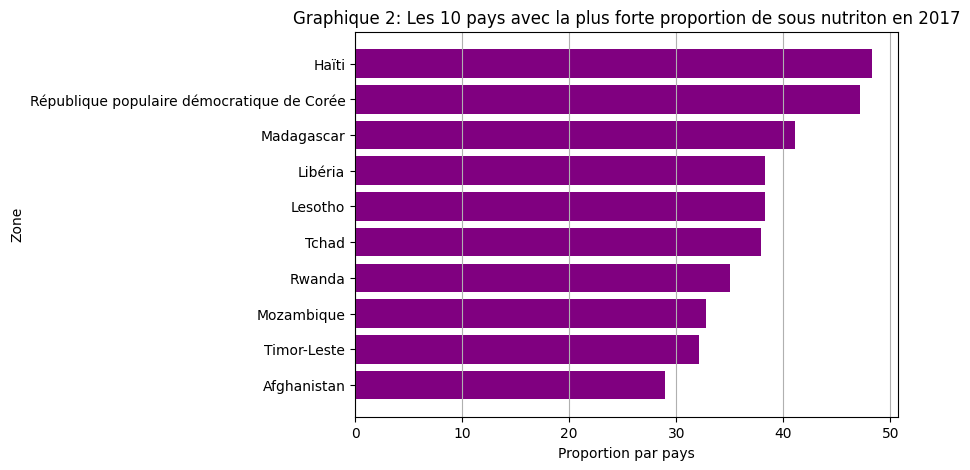

In [50]:
graphique= jointure.sort_values(by = ['Prop_sous_alim_par_pays'], ascending= False).head(10)
plt.figure(figsize=(7,5))
plt.barh(graphique['Zone'], graphique['Prop_sous_alim_par_pays'], color = 'purple')
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)
plt.grid(axis='x')
plt.title('Graphique 2: Les 10 pays avec la plus forte proportion de sous nutriton en 2017')
plt.ylabel('Zone', fontsize = 10)
plt.xlabel('Proportion par pays', fontsize = 10)
plt.gca().invert_yaxis() 

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.7 - Pays qui ont le plus bénéficié d'aide alimentaire depuis 2013</h3>
</div>

In [51]:
#calcul du total de l'aide alimentaire par pays
total_aide_alimentaire = aide_alimentaire.groupby(['Zone'])['Aide Alimentaire'].sum().reset_index()
total_aide_alimentaire.head()

,Zone,Aide Alimentaire
0,Afghanistan,185452000
1,Algérie,81114000
2,Angola,5014000
3,Bangladesh,348188000
4,Bhoutan,2666000


In [52]:
#affichage après trie des 10 pays qui ont bénéficié le plus de l'aide alimentaire
total_aide_alimentaire.sort_values(by = ['Aide Alimentaire'],ascending = False).head(10)

,Zone,Aide Alimentaire
50,République arabe syrienne,1858943000
75,Éthiopie,1381294000
70,Yémen,1206484000
61,Soudan du Sud,695248000
60,Soudan,669784000
30,Kenya,552836000
3,Bangladesh,348188000
59,Somalie,292678000
53,République démocratique du Congo,288502000
43,Niger,276344000


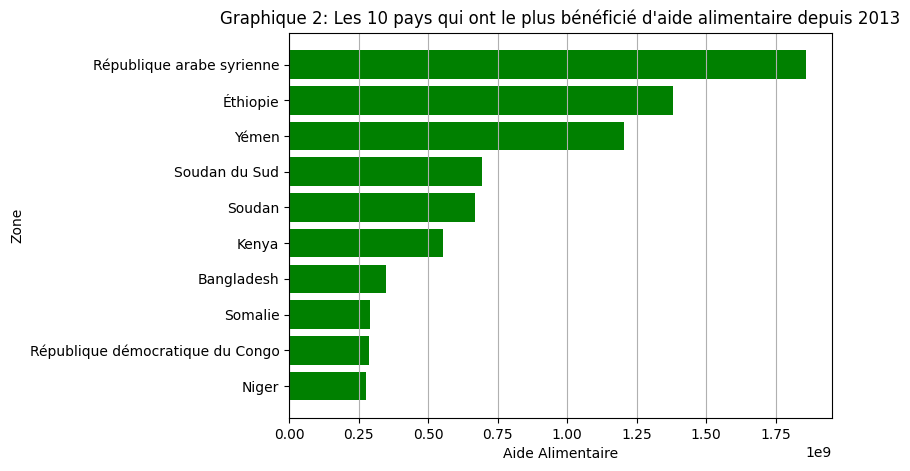

In [53]:
graphique2= total_aide_alimentaire.sort_values(by = ['Aide Alimentaire'],ascending = False).head(10)
plt.figure(figsize=(7,5))
plt.barh(graphique2['Zone'], graphique2['Aide Alimentaire'], color = 'green')
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)
plt.grid(axis='x')
plt.title("Graphique 2: Les 10 pays qui ont le plus bénéficié d'aide alimentaire depuis 2013")
plt.ylabel('Zone', fontsize = 10)
plt.xlabel('Aide Alimentaire', fontsize = 10)
plt.gca().invert_yaxis() 

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.8 - Evolution des 5 pays qui ont le plus bénéficiés de l'aide alimentaire entre 2013 et 2016</h3>
</div>

In [54]:
#Création d'une liste contenant les 5 pays qui ont le plus bénéficiées de l'aide alimentaire
cinq_pays = ['République arabe syrienne','Éthiopie','Yémen','Soudan du Sud','Soudan']
cinq_pays

['République arabe syrienne', 'Éthiopie', 'Yémen', 'Soudan du Sud', 'Soudan']

In [55]:
#Création d'un dataframe avec la zone, l'année et l'aide alimentaire puis groupby sur zone et année 
df_cinqpays = aide_alimentaire.loc[aide_alimentaire['Zone'].isin(cinq_pays), ['Zone', 'Année', 'Aide Alimentaire']]
df_cinqpays.head()

,Zone,Année,Aide Alimentaire
354,Éthiopie,2013,170000
355,Éthiopie,2014,466000
356,Éthiopie,2015,244000
357,Éthiopie,2013,181066000
358,Éthiopie,2014,178646000


In [56]:
#On filtre sur le dataframe avec notre liste
pivot5 = df_cinqpays.pivot_table(index='Année', columns='Zone', values='Aide Alimentaire', aggfunc='sum')
pivot5 = pivot5.reset_index()
pivot5.fillna(0, inplace=True)
pivot5

Zone,Année,République arabe syrienne,Soudan,Soudan du Sud,Yémen,Éthiopie
0,2013,563566000.0,330230000.0,196330000.0,264764000.0,591404000.0
1,2014,651870000.0,321904000.0,450610000.0,103840000.0,586624000.0
2,2015,524949000.0,17650000.0,48308000.0,372306000.0,203266000.0
3,2016,118558000.0,0.0,0.0,465574000.0,0.0


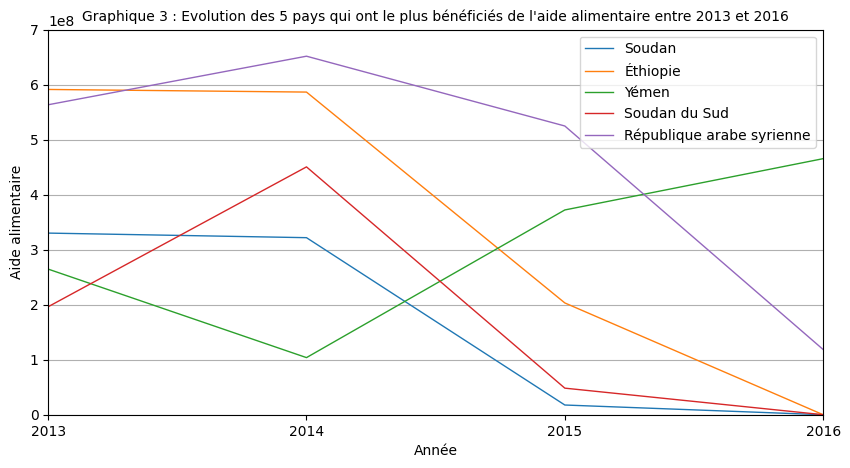

In [57]:
# Affichage des pays avec l'aide alimentaire par année
plt.figure(figsize=(10,5))
plt.plot(pivot5['Année'], pivot5['Soudan'], label = 'Soudan',linewidth=1)
plt.plot(pivot5['Année'], pivot5['Éthiopie'], label = 'Éthiopie',linewidth=1)
plt.plot(pivot5['Année'], pivot5['Yémen'], label = 'Yémen',linewidth=1)
plt.plot(pivot5['Année'], pivot5['Soudan du Sud'], label = 'Soudan du Sud',linewidth=1)
plt.plot(pivot5['Année'], pivot5['République arabe syrienne'], label = 'République arabe syrienne',linewidth=1)
plt.legend(loc='upper right')
plt.xlabel('Année', fontsize=10)
plt.ylabel('Aide alimentaire', fontsize=10)
plt.yticks(fontsize=10)
plt.title("Graphique 3 : Evolution des 5 pays qui ont le plus bénéficiés de l'aide alimentaire entre 2013 et 2016", fontsize='10')
plt.grid(axis='y')
plt.ylim(0 ,700000000)
plt.xlim(2013,2016)
plt.xticks([2013,2014,2015,2016])
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.9 - Pays avec le moins de disponibilité par habitant</h3>
</div>

In [58]:
#Calcul de la disponibilité en kcal par personne par jour par pays
dispo_par_personne_par_pays = dispo_alimentaire.groupby(['Zone'])['Disponibilité alimentaire (Kcal/personne/jour)'].sum()
dispo_par_personne_par_pays.head()

Zone
Afghanistan       2087.0
Afrique du Sud    3020.0
Albanie           3188.0
Algérie           3293.0
Allemagne         3503.0
Name: Disponibilité alimentaire (Kcal/personne/jour), dtype: float64

In [59]:
#Affichage des 10 pays qui ont le moins de dispo alimentaire par personne 
dispo_le_moins = dispo_par_personne_par_pays.sort_values().head(10)
dispo_le_moins = dispo_le_moins.reset_index()
dispo_le_moins

,Zone,Disponibilité alimentaire (Kcal/personne/jour)
0,République centrafricaine,1879.0
1,Zambie,1924.0
2,Madagascar,2056.0
3,Afghanistan,2087.0
4,Haïti,2089.0
5,République populaire démocratique de Corée,2093.0
6,Tchad,2109.0
7,Zimbabwe,2113.0
8,Ouganda,2126.0
9,Éthiopie,2129.0


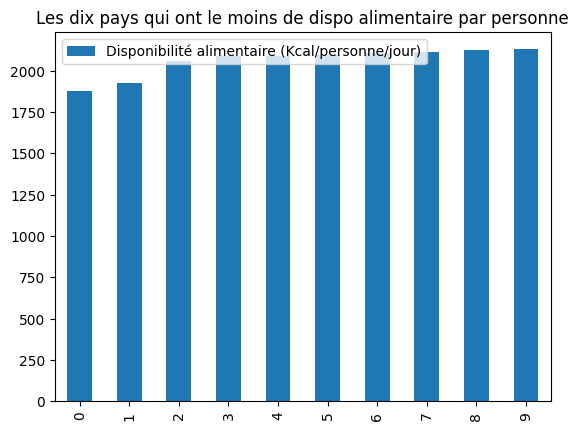

In [60]:
#Affichage des 10 pays qui ont le moins de dispo alimentaire par personne 
pays_moins_dispo = dispo_le_moins.sort_values(
    by="Disponibilité alimentaire (Kcal/personne/jour)", ascending=True
).head(10)
pays_moins_dispo.plot.bar(title="Les dix pays qui ont le moins de dispo alimentaire par personne")
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.10 - Pays avec le plus de disponibilité par habitant</h3>
</div>

In [61]:
#Affichage des 10 pays qui ont le plus de dispo alimentaire par personne 
dispo_le_plus = dispo_par_personne_par_pays.sort_values(ascending = False).head(10)
dispo_le_plus = dispo_le_plus.reset_index()
dispo_le_plus

,Zone,Disponibilité alimentaire (Kcal/personne/jour)
0,Autriche,3770.0
1,Belgique,3737.0
2,Turquie,3708.0
3,États-Unis d'Amérique,3682.0
4,Israël,3610.0
5,Irlande,3602.0
6,Italie,3578.0
7,Luxembourg,3540.0
8,Égypte,3518.0
9,Allemagne,3503.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.11 - Exemple de la Thaïlande pour le Manioc</h3>
</div>

In [62]:
#création d'un dataframe avec uniquement la Thaïlande 
thailande = dispo_alimentaire.loc[dispo_alimentaire['Zone'] == 'Thaïlande']
thailande.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
13759,Thaïlande,Abats Comestible,animale,0.0,0.0,3.0,1.11,0.09,0.56,74000.0,5000.0,33000.0,75000.0,0.0,45000.0,0.0,0.0,0.0
13760,Thaïlande,"Agrumes, Autres",vegetale,0.0,0.0,0.0,0.09,0.00,0.00,8000.0,6000.0,2000.0,6000.0,0.0,12000.0,0.0,2000.0,0.0
13761,Thaïlande,"Alcool, non Comestible",vegetale,0.0,358000.0,0.0,0.00,0.00,0.00,358000.0,110000.0,21000.0,0.0,0.0,447000.0,0.0,0.0,0.0
13762,Thaïlande,Aliments pour enfants,vegetale,0.0,0.0,2.0,0.18,0.01,0.08,12000.0,7000.0,19000.0,12000.0,0.0,0.0,0.0,0.0,0.0
13763,Thaïlande,Ananas,vegetale,0.0,0.0,10.0,10.02,0.04,0.08,782000.0,1449000.0,9000.0,671000.0,110000.0,2209000.0,0.0,0.0,13000.0


In [63]:
#Calcul de la sous nutrition en Thaïlande

prop_sous_alim_thailande = jointure.loc[jointure['Zone'] == 'Thaïlande']['Prop_sous_alim_par_pays'].sum()
print(f'La proportion de personnes en Thaïlande en sous nutrition est de {prop_sous_alim_thailande:.2f} %')

La proportion de personnes en Thaïlande en sous nutrition est de 8.96 %


In [64]:
# Disponibilté alimentaire par habitant pour la Thailande

print('La disponibilté alimentaire par habitatant en Thailande est de', thailande['Disponibilité alimentaire (Kcal/personne/jour)'].sum(), 'Kcal/personne/jour')

La disponibilté alimentaire par habitatant en Thailande est de 2785.0 Kcal/personne/jour


In [65]:
# Proportion de la production du manioc sur la production totale de la Thailande
manioc_total = thailande.loc[(thailande['Produit'] == 'Manioc')]
print('Le manioc représente', round(manioc_total['Production'].sum()*100/thailande['Production'].sum(),2), '% de toute la production de la Thailande')


Le manioc représente 14.98 % de toute la production de la Thailande


In [66]:
print('La Thaïlande produit', round(manioc_total['Production'].sum()), 'Tonnes de Manioc')

La Thaïlande produit 30228000 Tonnes de Manioc


In [67]:
# Proportion de manioc pour se nourrir

print('La Thailande utilise seulement', round(manioc_total['Nourriture'].sum()*100/manioc_total['Production'].sum(), 2), '% de sa production de manioc pour se nourrir')

La Thailande utilise seulement 2.88 % de sa production de manioc pour se nourrir


In [68]:
# Proportion de manioc exporté

print('La Thaïlande exporte', round(manioc_total['Exportations - Quantité'].sum()*100/manioc_total['Production'].sum(), 2),'% de sa production de manioc')
print('La Thaïlande exporte', round(manioc_total['Exportations - Quantité'].sum()), 'Tonnes de Manioc sur ses', 
      round(manioc_total['Production'].sum()), 'tonnes produits, soit uniquement',
      (round(manioc_total['Production'].sum()) - round(manioc_total['Exportations - Quantité'].sum())),'tonnes est utilisé pour son pays')

La Thaïlande exporte 83.41 % de sa production de manioc
La Thaïlande exporte 25214000 Tonnes de Manioc sur ses 30228000 tonnes produits, soit uniquement 5014000 tonnes est utilisé pour son pays


In [69]:
# Répartition de la disponibilité intérieure du manioc

repartition_disponibilite_intérieure_manioc = []

Liste_utilisation_produits_thailande = ['Aliments pour animaux', 'Pertes', 'Nourriture', 'Autres Utilisations']

for i in Liste_utilisation_produits_thailande:
    proportion = round(manioc_total[i].sum() * 100 / manioc_total['Disponibilité intérieure'].sum(), 2)
    print('Proportion de manioc pour', i, ':', proportion, '%')
    repartition_disponibilite_intérieure_manioc.append(proportion)


Proportion de manioc pour Aliments pour animaux : 28.74 %
Proportion de manioc pour Pertes : 24.12 %
Proportion de manioc pour Nourriture : 13.9 %
Proportion de manioc pour Autres Utilisations : 33.22 %


([<matplotlib.patches.Wedge at 0x1b4378446e0>,
 [Text(0.6811187685342922, 0.8637576182878676, 'Aliments pour animaux'),
  Text(-0.9215888958129591, 0.6005613266888328, 'Pertes'),
  Text(-0.8970954929517103, -0.6365686738488849, 'Nourriture'),
  Text(0.553190181957659, -0.9507789556914121, 'Autres Utilisations')],
 [Text(0.3715193282914321, 0.47114051906610954, '28.75%'),
  Text(-0.502684852261614, 0.327578905466636, '24.12%'),
  Text(-0.48932481433729647, -0.34721927664484625, '13.90%'),
  Text(0.3017400992496322, -0.5186067031044066, '33.23%')])

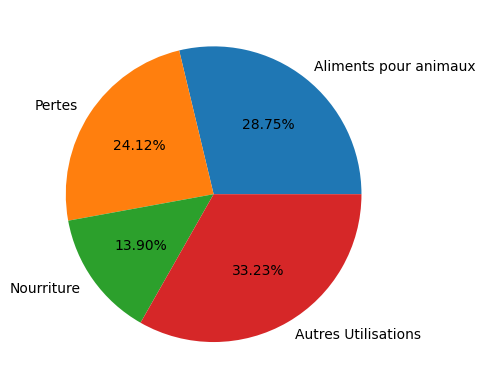

In [70]:
# Graphique 4:

plt.pie(repartition_disponibilite_intérieure_manioc, labels = Liste_utilisation_produits_thailande, autopct='%1.2f%%')

In [71]:
# 1 - La Thaïlande est un important producteur de manioc, et la demande mondiale pour ce produit peut inciter le pays à exporter une grande partie de sa production

# 2 - Le manioc est aussi utilisé pour d'autres applications, comme l'alimentation animale, produits industriels et autres

# 3 - Les politiques gouvernementales peuvent influencer les décisions d'exportation et de consommation intérieure

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 6 - Analyse complémentaires</h2>
</div>

In [72]:
#Rajouter en dessous toutes les analyses complémtaires suite à la demande de mélanie :
#"et toutes les infos que tu trouverais utiles pour mettre en relief les pays qui semblent être 
#le plus en difficulté au niveau alimentaire" 